## Get HRV-LF/HV ratio for all subs

-open question: take v1/v2 or v1raw or v2raw ? 
--> currently raw version does not work (no peaks detected for some runs)
--> checked that heart rate in bpm (beats per minute) seems reasonable: 
v1raw seems off (from 19-51), v1 good (70 & increasing over runs to 78), 
v2 good (76 & increasing over runs to 80), v2raw okay (randomly between 62-76)

[11.03.2025. : talked to Ella McPherson, she looked into TAPAS code, seem to take the 3rd row (ECG-1) - should correspond to `v1` !; also verified sampling rate of 500]

In [1]:
# env (sciencecloud): basic_env_stressrisk_ana

import neurokit2 as nk
import pandas as pd
import numpy as np
import os.path as op
import os
import matplotlib.pyplot as plt
import seaborn as sns

bids_folder = '/mnt_01/ds-stressrisk'
subList = [f[4:] for f in os.listdir(bids_folder) if f[0:3] == 'sub']
target_folder = op.join(bids_folder, 'interim_sum_data')

group_list = pd.read_csv(op.join(bids_folder, 'group_assignmentList.csv'))[['subject', 'group']].set_index('subject')   


In [ ]:
var = 'v2'
sampling_rate = 500

sub = '02'
ses = 1

data = []
for run in range(1,7):

    fn = op.join(bids_folder, f'sub-{sub}', f'ses-{ses}', 'func', f'sub-{sub}_ses-{ses}_task-risk_run-{run}_physio.log')
    df_physio = pd.read_csv(fn, sep=r'\s+', header=4, dtype=str) # '\t' #  delim_whitespace=True,, dtype=str
    df_physio.columns = list(df_physio.columns[1:]) + ['']
    df_physio = df_physio.drop(columns='')
    df_physio = df_physio.dropna(subset=[var]) # problematic?
    
    signals, info = nk.ecg_process( pd.to_numeric(df_physio[var], errors='coerce').values, sampling_rate=sampling_rate)
    ecg_signal = signals['ECG_Clean'].values
    peaks, info = nk.ecg_peaks(ecg_signal, sampling_rate=sampling_rate)

    #check that heart rate in bpm (beats per minute) seems reasonable
    hrv_time = nk.hrv_time(peaks, sampling_rate=sampling_rate, show=False)
    hr = hrv_time['HRV_MeanNN'].values[0]
    hr_bpm = 60/(hr * 0.001)
    print(np.round(hr_bpm,0).astype(int))

    hrv_freq = nk.hrv_frequency(peaks, sampling_rate=sampling_rate, show=False, normalize=True)
    hrv_lfhf =  hrv_freq['HRV_LFHF'].values[0]
    data.append({'subject': sub, 'session': ses, 'run': run, 'HRV_LFHF': hrv_lfhf})
    #plt.close('all')
    print(f'Done: {sub} {ses} {run}')

76
Done: 02 1 1
75
Done: 02 1 2
75
Done: 02 1 3
77
Done: 02 1 4
78
Done: 02 1 5
80
Done: 02 1 6


In [ ]:
var = 'v1'
sampling_rate = 500

data = []

for sub in subList:
    for ses in [1,2]:
        for run in range(1,7):
            try: 
                fn = op.join(bids_folder, f'sub-{sub}', f'ses-{ses}', 'func', f'sub-{sub}_ses-{ses}_task-risk_run-{run}_physio.log')
                df_physio = pd.read_csv(fn, sep=r'\s+', header=4, dtype=str) # '\t' #  delim_whitespace=True,, dtype=str
                df_physio.columns = list(df_physio.columns[1:]) + ['']
                df_physio = df_physio.drop(columns='')
                df_physio = df_physio.dropna(subset=[var]) # problematic?
                
                signals, info = nk.ecg_process( pd.to_numeric(df_physio[var], errors='coerce').values, sampling_rate=sampling_rate)
                ecg_signal = signals['ECG_Clean'].values
                peaks, info = nk.ecg_peaks(ecg_signal, sampling_rate=sampling_rate)

                #check that heart rate in bpm (beats per minute) seems reasonable
                hrv_time = nk.hrv_time(peaks, sampling_rate=sampling_rate, show=False)
                hr = hrv_time['HRV_MeanNN'].values[0]
                hr_bpm = np.round((60/(hr * 0.001)),1)

                hrv_freq = nk.hrv_frequency(peaks, sampling_rate=sampling_rate, show=False, normalize=True)
                hrv_lfhf =  hrv_freq['HRV_LFHF'].values[0]
                data.append({'subject': sub, 'session': ses, 'run': run, 
                            'HRV_LFHF': hrv_lfhf, 'HR_meanNN':hr, 'HR_bpm': hr_bpm,
                            'HRV_SDNN':hrv_time['HRV_SDNN'].values[0], 'HRV_RMSSD':hrv_time['HRV_RMSSD'].values[0],
                            })

            except:
                print(f'Error: {sub} {ses} {run}')
    print(f'Done: {sub} ')

df = pd.DataFrame(data)
df.to_csv(op.join(target_folder, f'HRV_var-{var}_sampRate-{sampling_rate}_subwise.csv'))
df.head()


## Load in 

v1 seems better; v2 has just huge range (HRV_LFHF)

In [2]:
var = 'v1'
spec = '' # _LFHF
sampling_rate = 500
df = pd.read_csv(op.join(target_folder, f'HRV_var-{var}_sampRate-{sampling_rate}{spec}_subwise.csv')).drop('Unnamed: 0', axis=1) # withour cleaning DF-name without 'sampRate'
df['subject'] = df['subject'].astype(int)
df = df.set_index(['subject','session','run']).join(group_list, on='subject').set_index('group', append=True)   
df.head()

HRV_LFHF   HR_meanNN  HR_bpm    HRV_SDNN  \
subject session run group                                             
12      1       1   0      0.668331  835.010101    71.9  180.858003   
                2   0      0.704098  871.611479    68.8  188.297423   
                3   0      0.928199  844.902386    71.0  126.731766   
                4   0      0.931359  873.064877    68.7  246.049054   
                5   0      0.683022  854.413187    70.2  251.349215   

                            HRV_RMSSD  
subject session run group              
12      1       1   0      239.364323  
                2   0      258.751666  
                3   0      154.622823  
                4   0      336.132901  
                5   0      344.307784

In [8]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)


/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 12.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 16.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


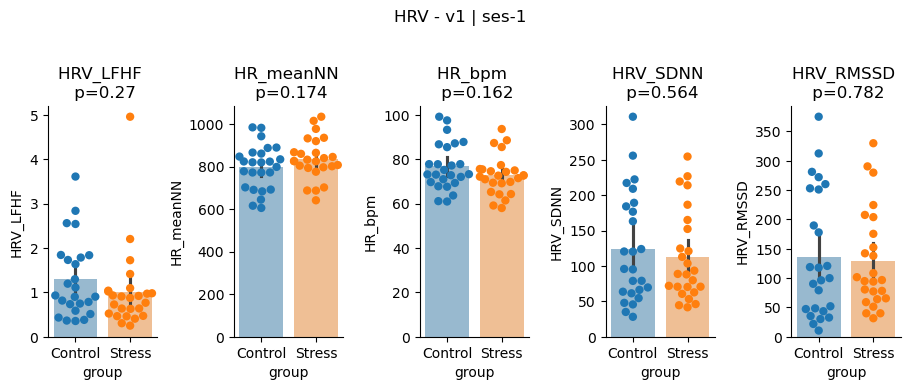

In [4]:
from scipy.stats import ttest_ind

ses = 1
tmp = df.groupby(['subject','session','group']).mean().xs(ses,0,level='session')
tmp = tmp.reset_index()
tmp['group'] = np.where(tmp['group'] == 0, 'Control', 'Stress')
tmp.set_index(['subject','group'], inplace=True)

fig, axs = plt.subplots(1,len(df.columns), figsize=(len(df.columns) * 2.2,3))
for i, y_var in enumerate(df.columns):

    sns.barplot(data=tmp.reset_index(), x ='group', y=y_var, hue='group',alpha=0.5,ax=axs[i]) #legend=False, 
    sns.swarmplot(data=tmp.reset_index(), x='group', hue='group', y=y_var, size=6, ax=axs[i],legend=False, )
    stats = ttest_ind(tmp.xs('Control',0,'group')[y_var], tmp.xs('Stress',0,'group')[y_var], axis=0, equal_var=False)
    p_val = np.round(stats.pvalue,3)
    axs[i].set(title=f'{y_var} \n p={p_val}')
    sns.despine()

fig.suptitle(f'HRV - {var} | ses-{ses}', y=1.2)
fig.subplots_adjust(wspace=0.7) 

/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 12.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


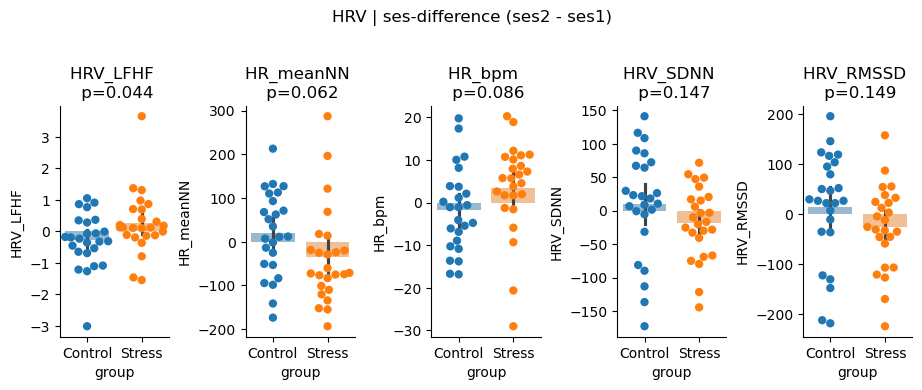

In [5]:
ses = 'difference (ses2 - ses1)'
tmp = df.groupby(['subject','session','group']).mean().xs(2,0,level='session') - df.groupby(['subject','session','group']).mean().xs(1,0,level='session')

tmp = tmp.reset_index()
tmp['group'] = np.where(tmp['group'] == 0, 'Control', 'Stress')
tmp.set_index(['subject','group'], inplace=True)

fig, axs = plt.subplots(1,len(df.columns), figsize=(len(df.columns) * 2.2,3))
for i, y_var in enumerate(df.columns):

    sns.barplot(data=tmp.reset_index(), x ='group', hue='group', y=y_var, alpha=0.5,ax=axs[i]) #legend=False, 
    sns.swarmplot(data=tmp.reset_index(), x='group', hue='group', y=y_var, size=6, ax=axs[i],legend=False, )
    stats = ttest_ind(tmp.xs('Control',0,'group')[y_var], tmp.xs('Stress',0,'group')[y_var], axis=0, equal_var=False)
    p_val = np.round(stats.pvalue,3)
    axs[i].set(title=f'{y_var} \n p={p_val}')
    sns.despine()

fig.suptitle(f'HRV | ses-{ses}', y=1.2)
fig.subplots_adjust(wspace=0.7) 

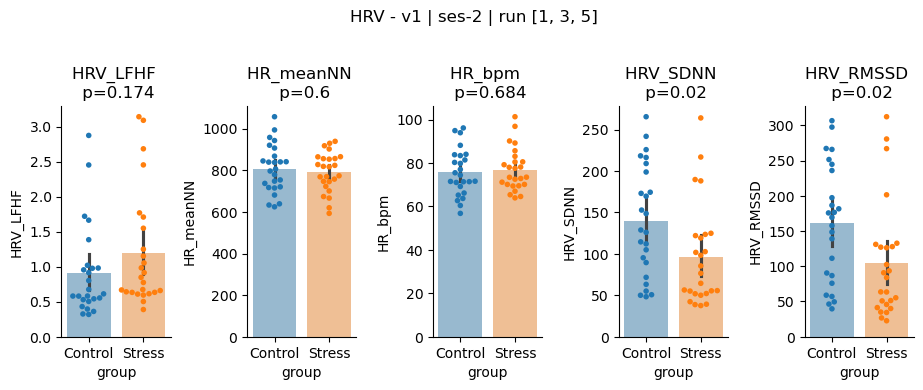

In [8]:
from scipy.stats import ttest_ind

ses = 2
runs = [1,3,5] # [2,4,6]#
tmp = pd.concat([df.xs(i,0,'run') for i in runs],axis=0)
#tmp = pd.concat([df.xs(1,0,'run'), df.xs(2,0,'run'),df.xs(3,0,'run')],axis=0)

tmp = tmp.groupby(['subject','session','group']).mean().xs(ses,0,level='session')
tmp = tmp.reset_index()
tmp['group'] = np.where(tmp['group'] == 0, 'Control', 'Stress')
tmp.set_index(['subject','group'], inplace=True)

fig, axs = plt.subplots(1,len(df.columns), figsize=(len(df.columns) * 2.2,3))
for i, y_var in enumerate(df.columns):

    sns.barplot(data=tmp.reset_index(), x ='group', hue='group', y=y_var, alpha=0.5,ax=axs[i]) #legend=False, 
    sns.swarmplot(data=tmp.reset_index(), x='group', hue='group', y=y_var, size=4, ax=axs[i],legend=False, )
    stats = ttest_ind(tmp.xs('Control',0,'group')[y_var], tmp.xs('Stress',0,'group')[y_var], axis=0, equal_var=False)
    p_val = np.round(stats.pvalue,3)
    axs[i].set(title=f'{y_var} \n p={p_val}')
    sns.despine()

fig.suptitle(f'HRV - {var} | ses-{ses} | run {runs}', y=1.2)
fig.subplots_adjust(wspace=0.7) 

# Correlations ?!

In [66]:
ses = 2
runs = range(1,7) #[1,3,5] # [2,4,6]#
tmp = pd.concat([df.xs(i,0,'run') for i in runs],axis=0)
tmp = tmp.groupby(['subject','session','group']).mean().xs(ses,0,level='session')

In [53]:
ses = 'difference (ses2 - ses1)'
tmp = df.groupby(['subject','session','group']).mean().xs(2,0,level='session') - df.groupby(['subject','session','group']).mean().xs(1,0,level='session')
runs ='all cause both sessions'

In [46]:
df_stress = pd.read_csv(op.join(bids_folder, 'addMeasures/selfRated_Stress_allMeasures.csv')).set_index('subject')
df_stress.head()

,group,q_stress_1,q_stress_2,q_stress_3,q_stress_4,q_stress_5,q_stress_6,q_stress_7,mean_stress,min-max_diff,sd_stress,auc_stress,auc_stress_old,AUC,group.1
subject,,,,,,,,,,,,,,,
1,0,5,5,4,5,5,5,4,6.981949,1.0,7.323603,1.5,28.5,2.060,control
2,0,2,2,2,2,2,2,1,2.843103,1.0,2.932727,2.5,11.5,-0.505,control
3,1,5,6,5,5,6,2,3,7.110147,4.0,7.105554,4.0,28.0,3.530,stress
4,1,4,5,6,5,5,4,3,7.074323,3.0,7.247450,7.5,28.5,1.055,stress
5,0,1,2,2,1,3,1,1,2.557188,2.0,2.573373,4.0,10.0,-0.635,control


In [51]:
df_comb = tmp.join(df_stress, on='subject').dropna()

In [54]:
print(f'ses-{ses} | runs-{runs} \n')
for y_var in tmp.columns:
    for x_var in ['mean_stress','AUC']:
        corr, p_value = pearsonr(df_comb[y_var], df_comb[x_var])
        print(f'{y_var} vs {x_var} | r={corr:.3f} | p={p_value:.3f}')

ses-difference (ses2 - ses1) | runs-all cause both sessions 

HRV_LFHF vs mean_stress | r=0.240 | p=0.096
HRV_LFHF vs AUC | r=0.172 | p=0.239
HR_meanNN vs mean_stress | r=-0.243 | p=0.093
HR_meanNN vs AUC | r=-0.331 | p=0.020
HR_bpm vs mean_stress | r=0.257 | p=0.075
HR_bpm vs AUC | r=0.286 | p=0.046
HRV_SDNN vs mean_stress | r=-0.061 | p=0.675
HRV_SDNN vs AUC | r=-0.004 | p=0.978
HRV_RMSSD vs mean_stress | r=-0.063 | p=0.667
HRV_RMSSD vs AUC | r=-0.029 | p=0.841


Pearson correlation: -0.2661770101641627, p-value: 0.06450905991527914


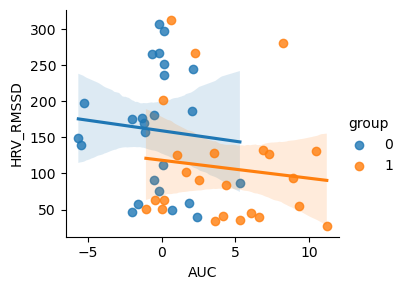

In [49]:
y_var= 'HRV_RMSSD'
x_var = 'AUC'

from scipy.stats import pearsonr
df_comb = df_comb.dropna()

corr, p_value = pearsonr(df_comb[y_var], df_comb[x_var])
print(f'Pearson correlation: {corr}, p-value: {p_value}')

sns.lmplot(data=df_comb, x=x_var, y=y_var, hue='group', height=3, aspect=1.2) 

In [67]:
df_p_shift = pd.read_csv(op.join(bids_folder, 'interim_sum_data/subwise_change_prior_model-5.csv')).set_index('subject')
df_n_shift = pd.read_csv(op.join(bids_folder, 'interim_sum_data/r-prior-shift_Ediff_AUC.csv')).set_index('subject')

df_comb = tmp.join(df_p_shift, on='subject').join(df_n_shift, on='subject').dropna()

In [68]:
print(f'ses-{ses} | runs-{runs} \n')
for y_var in tmp.columns:
    for x_var in ['prior_mu','E_dif']:
        corr, p_value = pearsonr(df_comb[y_var], df_comb[x_var])
        print(f'{y_var} vs {x_var} | r={corr:.3f} | p={p_value:.3f}')

ses-2 | runs-range(1, 7) 

HRV_LFHF vs prior_mu | r=0.070 | p=0.637
HRV_LFHF vs E_dif | r=0.092 | p=0.534
HR_meanNN vs prior_mu | r=0.015 | p=0.918
HR_meanNN vs E_dif | r=0.012 | p=0.937
HR_bpm vs prior_mu | r=-0.012 | p=0.936
HR_bpm vs E_dif | r=-0.004 | p=0.976
HRV_SDNN vs prior_mu | r=-0.136 | p=0.357
HRV_SDNN vs E_dif | r=-0.044 | p=0.765
HRV_RMSSD vs prior_mu | r=-0.134 | p=0.364
HRV_RMSSD vs E_dif | r=-0.048 | p=0.744
